**M ARISH SC25M159**

**MA642 Advanced Machine Learning Lab**

**Assignment-II**

**2. Analyse Data 1 using ICA**


In [ ]:
# Data Processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

Load Data

In [ ]:
# Load the CSV file
data1 = pd.read_csv("Data1.csv")

# Display first few rows to check
print("Data 1 -", (data1.shape)) # prints number of rows and columns
print(type(data1))
print(data1.head())
data1.keys()


Data 1 - (2000, 4)
<class 'pandas.core.frame.DataFrame'>
   Unnamed: 0         0         1         2
0           0 -0.744863 -0.914015 -1.815700
1           1  0.039325  1.064930 -1.587150
2           2 -0.407660  0.397869 -1.909981
3           3  0.033789  0.967298 -1.014872
4           4 -0.179156  0.695176 -1.491172


Index(['Unnamed: 0', '0', '1', '2'], dtype='object')

ICA - Independent Component Analysis

In [ ]:
X_features = data1[:, 1:]
X = X_features.T # (3,2000)
print("Shape after dropping index column and transposing:", X.shape)

Shape after dropping index column and transposing: (3, 2000)


In [ ]:
X

array([[-0.74486315,  0.03932519, -0.40766041, ...,  0.23856791,
        -0.00653213, -3.00301507],
       [-0.91401507,  1.06492993,  0.39786915, ..., -0.28486909,
        -0.99317023, -3.62816891],
       [-1.81570038, -1.58715033, -1.90998106, ...,  1.38619226,
         1.48134842, -4.8258685 ]])

In [ ]:
n_components = 3      # number of sources
max_iter = 1000
tol = 1e-5
learning_rate = 0.01

# CENTERING
X_mean = np.mean(X, axis=1, keepdims=True)
X_centered = X - X_mean

# WHITENING
cov = np.cov(X_centered)

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(cov)

# Whitening matrix
D_inv = np.diag(1.0 / np.sqrt(eigvals))
whitening_matrix = D_inv @ eigvecs.T

X_white = whitening_matrix @ X_centered

# FAST ICA
def g(u):
    return np.tanh(u)

def g_derivative(u):
    return 1 - np.tanh(u)**2

# Initialize unmixing matrix
W = np.random.randn(n_components, n_components)

for i in range(max_iter):
    W_old = W.copy()

    WX = W @ X_white
    GWX = g(WX)
    G_der = g_derivative(WX)

    # Gradient update rule
    W = (GWX @ X_white.T) / X_white.shape[1] - np.diag(np.mean(G_der, axis=1)) @ W

    # Decorrelate W (orthogonalization)
    U, _, Vt = np.linalg.svd(W)
    W = U @ Vt

    # Check convergence
    if np.max(np.abs(np.abs(np.diag(W @ W_old.T)) - 1)) < tol:
        print("Converged at iteration:", i)
        break

# (b) SOURCE SIGNALS
S = W @ X_white   # Recovered independent sources

print("Source Signals Shape:", S.shape)  # (3, 2000)

Converged at iteration: 3
Source Signals Shape: (3, 2000)


(a) Report the values of the parameters.

In [ ]:
print("Parameters")
print("Components:", n_components)
print("Max Iterations:", max_iter)
print("Tolerance:", tol)
print("Learning Rate:", learning_rate)
print("Converged in iterations:", i)
print("\nEstimated ICA parameters (W):", W.shape)
print(W)
print("\nWhitened Shape:", X_white.shape)
print(whitening_matrix)


Parameters
Components: 3
Max Iterations: 1000
Tolerance: 1e-05
Learning Rate: 0.01
Converged in iterations: 3

Estimated ICA parameters (W): (3, 3)
[[ 0.61534762  0.43557425 -0.65697974]
 [ 0.09063363  0.78883587  0.60788446]
 [-0.783028    0.43360471 -0.4459306 ]]

Whitened Shape: (3, 2000)
[[-3.86526479  1.06079607  1.72972016]
 [ 0.04451986 -0.68043119  0.51677712]
 [-0.1242833  -0.1494502  -0.18607152]]


(b) Find the source signals.

In [ ]:
print("\nRecovered source signals :", S.shape)
print(S)


Recovered source signals : (3, 2000)
[[-1.28631549 -1.85004678 -1.59103406 ...  1.28014262  1.65070712
  -1.62678772]
 [-0.00299639 -1.2579901  -0.87451487 ...  0.72341863  1.23856657
   0.96330273]
 [ 0.39328322  0.4901834   0.14848832 ... -0.57660653 -0.68629777
  -0.58289196]]


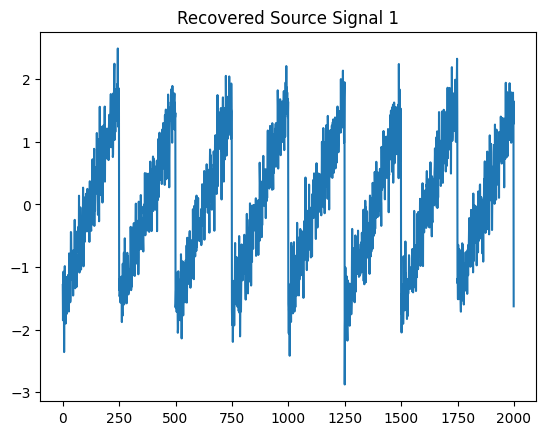

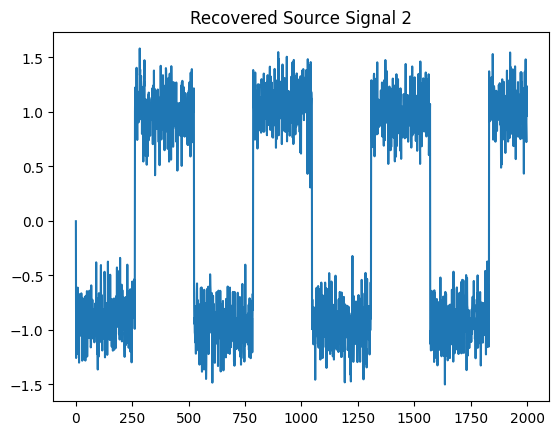

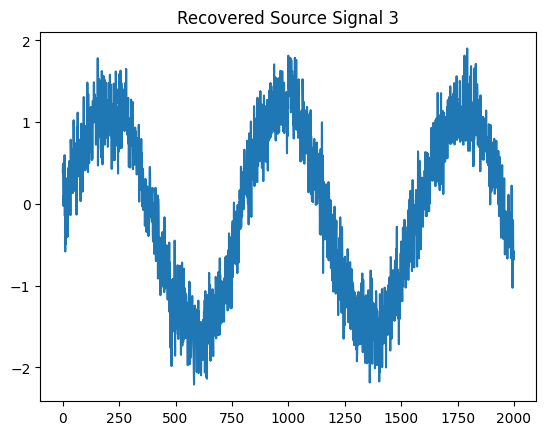

In [ ]:
import matplotlib.pyplot as plt

for i in range(n_components):
    plt.plot(S[i])
    plt.title(f"Recovered Source Signal {i+1}")
    plt.show()